# XGBoost: Credit Risk Scoring & Credit Limit Prediction

**Objective:** Classify customer risk and predict credit limits
- **Task 1:** Risk Classification (High/Low)
- **Task 2:** Credit Limit Regression (USD amount)

In [1]:
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, ConfusionMatrixDisplay
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('outputs', exist_ok=True)

## Dataset Generation

In [2]:
def generate_b2b_dataset(n_samples=1000):
    rng = np.random.default_rng(42)
    annual_income = rng.lognormal(mean=11.5, sigma=0.6, size=n_samples)
    annual_income = np.clip(annual_income, 50_000, 2_000_000).round(-2)
    debt_ratio = rng.uniform(0.05, 0.80, size=n_samples)
    current_debt = (annual_income * debt_ratio).round(-2)
    years_in_business = np.clip(rng.exponential(scale=4, size=n_samples), 1, 30).astype(int)
    prev_missed_payments = np.clip(rng.poisson(lam=1.5, size=n_samples), 0, 8)
    avg_order_value = (annual_income * rng.uniform(0.002, 0.015, size=n_samples)).round(-1)
    
    risk_logit = (-2.0 + 3.0 * debt_ratio + 0.4 * prev_missed_payments 
                  - 0.15 * np.log1p(years_in_business) + 0.000001 * annual_income 
                  + rng.normal(0, 0.3, n_samples))
    risk_prob = 1 / (1 + np.exp(-risk_logit))
    high_risk = (rng.uniform(size=n_samples) < risk_prob).astype(int)
    risk_multiplier = np.where(high_risk == 1, 0.7, 1.0)
    credit_limit = (annual_income * 0.35 * (1 - debt_ratio) * (1 + 0.02 * years_in_business) 
                    * (0.8 ** prev_missed_payments) * risk_multiplier + rng.normal(0, 2000, n_samples))
    credit_limit = np.clip(credit_limit, 5_000, 500_000).round(-2)
    
    return pd.DataFrame({
        'Annual_Income': annual_income, 'Current_Debt': current_debt,
        'Years_in_Business': years_in_business, 'Previous_Missed_Payments': prev_missed_payments,
        'Average_Order_Value': avg_order_value, 'High_Risk': high_risk, 'Credit_Limit': credit_limit,
    })

df = generate_b2b_dataset(1000)
df.to_csv('outputs/credit_risk_dataset.csv', index=False)
print(f'Dataset: {df.shape} | Class: {dict(df["High_Risk"].value_counts())}')

Dataset: (1000, 7) | Class: {0: np.int64(560), 1: np.int64(440)}


## Preprocessing & Split

In [3]:
X = df[['Annual_Income', 'Current_Debt', 'Years_in_Business', 'Previous_Missed_Payments', 'Average_Order_Value']].values
y_risk = df['High_Risk'].values
y_credit = df['Credit_Limit'].values

X_train, X_test, y_risk_train, y_risk_test, y_credit_train, y_credit_test = train_test_split(
    X, y_risk, y_credit, test_size=0.20, random_state=42, stratify=y_risk)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training

In [4]:
xgb_clf = XGBClassifier(n_estimators=200, learning_rate=0.08, max_depth=5, subsample=0.8,
                        colsample_bytree=0.85, lambda_=1.0, alpha=0.1, random_state=42, verbosity=0)
xgb_clf.fit(X_train_scaled, y_risk_train)

xgb_reg = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.85,
                       colsample_bytree=0.80, lambda_=2.0, alpha=0.2, random_state=42, verbosity=0)
xgb_reg.fit(X_train_scaled, y_credit_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Results

In [5]:
y_risk_pred = xgb_clf.predict(X_test_scaled)
y_risk_proba = xgb_clf.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_risk_test, y_risk_pred)
prec = precision_score(y_risk_test, y_risk_pred)
rec = recall_score(y_risk_test, y_risk_pred)
f1 = f1_score(y_risk_test, y_risk_pred)
auc = roc_auc_score(y_risk_test, y_risk_proba)

print('CLASSIFICATION (Risk Scoring)')
print('='*40)
print(f'Accuracy : {acc:.4f} | Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f} | F1-Score : {f1:.4f}')
print(f'ROC-AUC  : {auc:.4f}\n')
print(classification_report(y_risk_test, y_risk_pred, target_names=['Low Risk', 'High Risk']))

CLASSIFICATION (Risk Scoring)
Accuracy : 0.7100 | Precision: 0.6875
Recall   : 0.6250 | F1-Score : 0.6548
ROC-AUC  : 0.7359

              precision    recall  f1-score   support

    Low Risk       0.72      0.78      0.75       112
   High Risk       0.69      0.62      0.65        88

    accuracy                           0.71       200
   macro avg       0.71      0.70      0.70       200
weighted avg       0.71      0.71      0.71       200



In [6]:
y_credit_pred = xgb_reg.predict(X_test_scaled)

mse = mean_squared_error(y_credit_test, y_credit_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_credit_test, y_credit_pred)
r2 = r2_score(y_credit_test, y_credit_pred)

print('REGRESSION (Credit Limit Prediction)')
print('='*40)
print(f'MSE  : ${mse:,.2f}')
print(f'RMSE : ${rmse:,.2f}')
print(f'MAE  : ${mae:,.2f}')
print(f'R²   : {r2:.4f}')

REGRESSION (Credit Limit Prediction)
MSE  : $27,335,144.90
RMSE : $5,228.30
MAE  : $3,460.95
R²   : 0.8192


In [7]:
# Evaluate on training set to check for overfitting
y_risk_train_pred = xgb_clf.predict(X_train_scaled)
y_risk_train_proba = xgb_clf.predict_proba(X_train_scaled)[:, 1]

train_acc = accuracy_score(y_risk_train, y_risk_train_pred)
train_f1 = f1_score(y_risk_train, y_risk_train_pred)
train_auc = roc_auc_score(y_risk_train, y_risk_train_proba)

print('TRAINING CLASSIFICATION (Risk Scoring)')
print('='*40)
print(f'Accuracy : {train_acc:.4f} | F1-Score : {train_f1:.4f}')
print(f'ROC-AUC  : {train_auc:.4f}\n')

y_credit_train_pred = xgb_reg.predict(X_train_scaled)

train_mse = mean_squared_error(y_credit_train, y_credit_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_credit_train, y_credit_train_pred)
train_r2 = r2_score(y_credit_train, y_credit_train_pred)

print('TRAINING REGRESSION (Credit Limit Prediction)')
print('='*40)
print(f'MSE  : ${train_mse:,.2f}')
print(f'RMSE : ${train_rmse:,.2f}')
print(f'MAE  : ${train_mae:,.2f}')
print(f'R²   : {train_r2:.4f}')

print('\nOVERFITTING CHECK:')
print('='*40)
print('If training metrics are significantly better than test metrics, the model may be overfitting.')
print(f'Classification - Train Acc: {train_acc:.4f} vs Test Acc: {acc:.4f} (Gap: {train_acc - acc:.4f})')
print(f'Classification - Train AUC: {train_auc:.4f} vs Test AUC: {auc:.4f} (Gap: {train_auc - auc:.4f})')
print(f'Regression - Train R²: {train_r2:.4f} vs Test R²: {r2:.4f} (Gap: {train_r2 - r2:.4f})')

TRAINING CLASSIFICATION (Risk Scoring)
Accuracy : 0.9663 | F1-Score : 0.9610
ROC-AUC  : 0.9947

TRAINING REGRESSION (Credit Limit Prediction)
MSE  : $779,947.65
RMSE : $883.15
MAE  : $665.25
R²   : 0.9957

OVERFITTING CHECK:
If training metrics are significantly better than test metrics, the model may be overfitting.
Classification - Train Acc: 0.9663 vs Test Acc: 0.7100 (Gap: 0.2563)
Classification - Train AUC: 0.9947 vs Test AUC: 0.7359 (Gap: 0.2588)
Regression - Train R²: 0.9957 vs Test R²: 0.8192 (Gap: 0.1765)


## Visualization

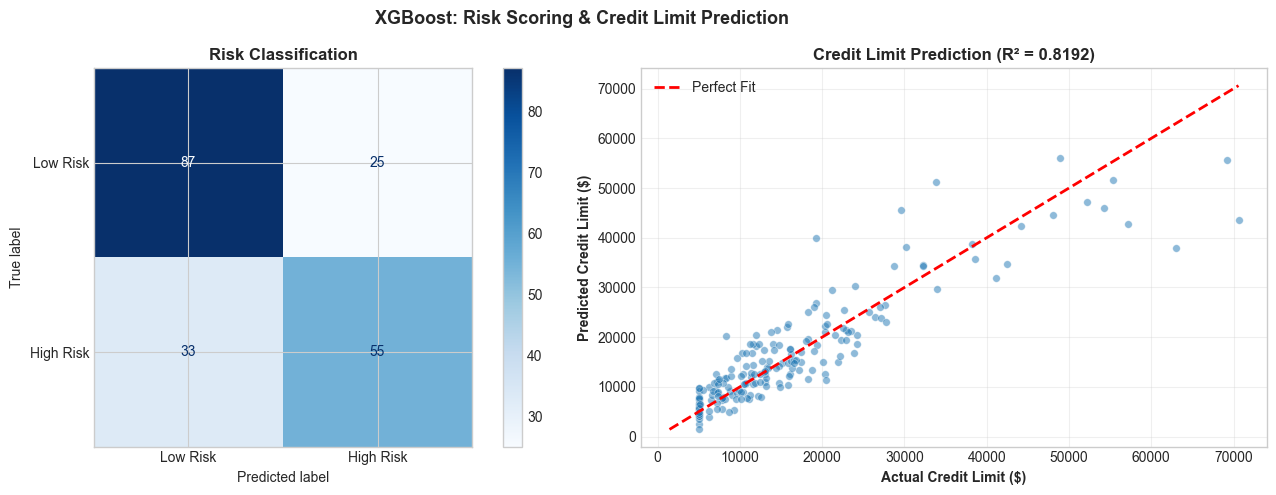

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost: Risk Scoring & Credit Limit Prediction', fontsize=13, fontweight='bold')

cm = confusion_matrix(y_risk_test, y_risk_pred)
ConfusionMatrixDisplay(cm, display_labels=['Low Risk', 'High Risk']).plot(ax=axes[0], colorbar=True, cmap='Blues')
axes[0].set_title('Risk Classification', fontweight='bold')

axes[1].scatter(y_credit_test, y_credit_pred, alpha=0.5, s=30, color='#1f77b4', edgecolors='white', linewidth=0.5)
lims = [min(y_credit_test.min(), y_credit_pred.min()), max(y_credit_test.max(), y_credit_pred.max())]
axes[1].plot(lims, lims, 'r--', lw=2, label='Perfect Fit')
axes[1].set_xlabel('Actual Credit Limit ($)', fontweight='bold')
axes[1].set_ylabel('Predicted Credit Limit ($)', fontweight='bold')
axes[1].set_title(f'Credit Limit Prediction (R² = {r2:.4f})', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/credit_risk_scoring_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Export Results

In [9]:
results_export = pd.DataFrame({
    'Actual_Risk': y_risk_test,
    'Predicted_Risk': y_risk_pred,
    'Risk_Probability': y_risk_proba,
    'Actual_Credit_Limit': y_credit_test,
    'Predicted_Credit_Limit': y_credit_pred,
    'Prediction_Error': np.abs(y_credit_test - y_credit_pred)
})
results_export.to_csv('outputs/credit_risk_predictions.csv', index=False)

print('\nExport Complete:')
print('  • credit_risk_dataset.csv')
print('  • credit_risk_predictions.csv')
print('  • credit_risk_scoring_results.png')


Export Complete:
  • credit_risk_dataset.csv
  • credit_risk_predictions.csv
  • credit_risk_scoring_results.png


In [10]:
import joblib

# پاشەکەوتکردنی مۆدێلەکە و پاککەرەوەی داتاکە (Scaler)
# تێبینی: پێویستە ناوی گۆڕاوەکان ڕێک ئەوانە بن کە لە کۆدەکەتدا بەکارت هێناون
joblib.dump(xgb_clf, 'outputs/risk_model.joblib')
joblib.dump(xgb_reg, 'outputs/limit_model.joblib')
joblib.dump(scaler, 'outputs/scaler.joblib')

print("Models successfully saved to 'outputs' folder!")

Models successfully saved to 'outputs' folder!
